<a href="https://colab.research.google.com/github/devashishpalod59-sketch/Fake-identity-And-Document-Screening-System/blob/main/Fake_Identity_and_document_Screening_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Project Overview

This project aims to develop an AI-powered system capable of screening identities and documents to detect counterfeits or fraudulent activities. The system will leverage machine learning and computer vision techniques to analyze provided documents and identity information, cross-referencing them for consistency and authenticity.

### Next Steps:

To begin, we need to consider how to acquire a suitable dataset for this task. Given the sensitivity of identity documents, public datasets might be limited, or we may need to explore synthetic data generation or focus on publicly available research datasets.

In [1]:
import os
import tensorflow as tf
import numpy as np
from PIL import Image, ImageDraw, ImageFont, ImageFilter
import random

# --- Configuration for Dataset and Image Generation ---
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
dataset_dir = './dummy_document_data'
gen_dir = os.path.join(dataset_dir, 'genuine')
fake_dir = os.path.join(dataset_dir, 'fake')

# Ensure base directories exist
os.makedirs(gen_dir, exist_ok=True)
os.makedirs(fake_dir, exist_ok=True)

# --- Synthetic Data Generation Helper Functions (Moved from b744d11b) ---
def add_noise(img):
    """Adds random Gaussian noise to the image."""
    img_array = np.array(img).astype(np.float32)
    noise = np.random.normal(0, 15, img_array.shape)
    noisy_img = np.clip(img_array + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(noisy_img)

def add_distortion(img):
    """Applies a subtle distortion/warp effect."""
    img = img.transform(img.size, Image.AFFINE, (1, random.uniform(-0.05, 0.05), random.uniform(-10, 10),
                                                  0, 1, random.uniform(-0.05, 0.05)))
    return img

def generate_synthetic_document(is_fake=False, document_type='passport', img_idx=0):
    img_width, img_height = 800, 600
    # More varied and slightly textured backgrounds
    bg_color_base = (random.randint(220, 240), random.randint(220, 240), random.randint(220, 240))
    bg_img = Image.new('RGB', (img_width, img_height), color=bg_color_base)
    # Add some random lines or faint patterns to simulate paper texture
    draw_bg = ImageDraw.Draw(bg_img)
    for _ in range(5):
        line_color = (random.randint(200, 210), random.randint(200, 210), random.randint(200, 210))
        draw_bg.line([(random.randint(0, img_width), random.randint(0, img_height)),
                      (random.randint(0, img_width), random.randint(0, img_height))], fill=line_color, width=1)
    img = bg_img
    d = ImageDraw.Draw(img)

    # Try to load a more interesting font, or fall back to default
    try:
        font_path = '/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf'
        title_font = ImageFont.truetype(font_path, 36) if os.path.exists(font_path) else ImageFont.load_default()
        text_font = ImageFont.truetype(font_path, 24) if os.path.exists(font_path) else ImageFont.load_default()
        small_text_font = ImageFont.truetype(font_path, 18) if os.path.exists(font_path) else ImageFont.load_default()
    except Exception:
        title_font = ImageFont.load_default()
        text_font = ImageFont.load_default()
        small_text_font = ImageFont.load_default()

    # Base document content
    d.text((random.randint(50, 70), random.randint(50, 70)),
           f"{document_type.upper()} IDENTITY DOCUMENT", fill=(random.randint(30, 50), random.randint(30, 50), random.randint(30, 50)), font=title_font)
    d.text((random.randint(50, 70), random.randint(120, 140)),
           f"Name: {random.choice(['John Doe', 'Jane Smith', 'Alice Johnson', 'Bob Williams', 'Charlie Brown'])}",
           fill=(random.randint(0, 20), random.randint(0, 20), random.randint(0, 20)), font=text_font)
    d.text((random.randint(50, 70), random.randint(170, 190)),
           f"ID No: {random.randint(100000000, 999999999)}",
           fill=(random.randint(0, 20), random.randint(0, 20), random.randint(0, 20)), font=text_font)
    d.text((random.randint(50, 70), random.randint(220, 240)),
           f"DOB: {random.randint(1, 28):02d}/{random.randint(1, 12):02d}/{random.randint(1950, 2000)}",
           fill=(random.randint(0, 20), random.randint(0, 20), random.randint(0, 20)), font=text_font)
    d.text((random.randint(50, 70), random.randint(270, 290)),
           f"Nationality: {random.choice(['USA', 'CAN', 'GBR', 'AUS', 'GER', 'FRA', 'JPN', 'IND'])}",
           fill=(random.randint(0, 20), random.randint(0, 20), random.randint(0, 20)), font=text_font)

    # Simulate a photo placeholder
    photo_x, photo_y = random.randint(500, 600), random.randint(100, 150)
    photo_width, photo_height = 120, 150
    d.rectangle([photo_x, photo_y, photo_x + photo_width, photo_y + photo_height], fill=(random.randint(150, 200), random.randint(150, 200), random.randint(150, 200)), outline=(50,50,50))
    d.text((photo_x + 10, photo_y + photo_height // 2 - 10), "Photo", fill=(255,255,255), font=small_text_font)


    if is_fake:
        forgery_type = random.choice(['patch', 'blur', 'overlap', 'color_shift', 'watermark_alteration', 'photo_replacement', 'text_mismatch'])
        if forgery_type == 'patch':
            # Patch over some text
            patch_x = random.randint(100, 400)
            patch_y = random.randint(150, 300)
            patch_width = random.randint(100, 200)
            patch_height = random.randint(20, 40)
            d.rectangle([patch_x, patch_y, patch_x + patch_width, patch_y + patch_height], fill=(random.randint(200,230), random.randint(200,230), random.randint(200,230)))
            d.text((patch_x + 5, patch_y + 5), "FAKE DATA", fill=(random.randint(0, 100), random.randint(0, 100), random.randint(0, 100)), font=small_text_font)
        elif forgery_type == 'blur':
            # Blur a section of the document
            blur_x = random.randint(50, img_width - 200)
            blur_y = random.randint(100, img_height - 100)
            blur_region = img.crop((blur_x, blur_y, blur_x + 150, blur_y + 100))
            blur_region = blur_region.filter(ImageFilter.GaussianBlur(radius=random.uniform(1.5, 3)))
            img.paste(blur_region, (blur_x, blur_y))
        elif forgery_type == 'overlap':
            # Overlapping text/stamp
            d.text((random.randint(50, img_width-200), random.randint(350, img_height-100)),
                   random.choice(["VOID", "COPY", "INVALID", "UNAUTHORIZED"]),
                   fill=(random.randint(150, 200), random.randint(50, 100), random.randint(50, 100)),
                   font=title_font)
        elif forgery_type == 'color_shift':
            # Apply a color shift to a specific area
            shift_x = random.randint(50, img_width - 200)
            shift_y = random.randint(50, img_height - 200)
            shift_region = img.crop((shift_x, shift_y, shift_x + 150, shift_y + 150))
            shift_region_array = np.array(shift_region).astype(np.int32)
            color_offset = (random.randint(-30, 30), random.randint(-30, 30), random.randint(-30, 30))
            shifted_array = np.clip(shift_region_array + color_offset, 0, 255).astype(np.uint8)
            img.paste(Image.fromarray(shifted_array), (shift_x, shift_y))
        elif forgery_type == 'watermark_alteration':
            # Add a faint, distorted watermark
            watermark_text = random.choice(["SECRET", "CONFIDENTIAL", "DRAFT"])
            watermark_color = (random.randint(180, 220), random.randint(180, 220), random.randint(180, 220), 100) # Semi-transparent
            watermark_img = Image.new('RGBA', (img_width, img_height), (0,0,0,0))
            draw_wm = ImageDraw.Draw(watermark_img)
            draw_wm.text((random.randint(img_width//4, img_width//2), random.randint(img_height//4, img_height//2)),
                         watermark_text, fill=watermark_color, font=ImageFont.truetype(font_path, 70) if os.path.exists(font_path) else ImageFont.load_default(), anchor="mm")
            watermark_img = watermark_img.rotate(random.uniform(-30, 30), expand=True, fillcolor=(0,0,0,0))
            img.paste(watermark_img, (0, 0), watermark_img)
        elif forgery_type == 'photo_replacement':
            # Simulate a crudely replaced photo
            d.rectangle([photo_x, photo_y, photo_x + photo_width, photo_y + photo_height], fill=(random.randint(50, 100), random.randint(50, 100), random.randint(50, 100)), outline=(200, 0, 0), width=3)
            d.text((photo_x + 10, photo_y + photo_height // 2 - 10), "REPLACED", fill=(255,255,255), font=small_text_font)
        elif forgery_type == 'text_mismatch':
            # Change a single piece of text to something inconsistent
            # Overwrite name with a different, slightly off name
            d.text((random.randint(50, 70), random.randint(120, 140)),
                   f"Name: {random.choice(['Richard Roe', 'Betty White', 'Chris Green'])}",
                   fill=(random.randint(0, 20), random.randint(0, 20), random.randint(0, 20)), font=text_font)

    img = add_noise(img)
    img = add_distortion(img)
    img = img.filter(ImageFilter.SMOOTH)
    return img

# --- Generate Synthetic Data (Execution Part from b744d11b) ---
print(f"Generating synthetic documents in: {dataset_dir}")

# Clear existing directories to avoid mixing old and new data
# This also ensures we start fresh if the cell is re-run.
for directory in [gen_dir, fake_dir]:
    if os.path.exists(directory):
        for f in os.listdir(directory):
            os.remove(os.path.join(directory, f))

num_samples = 500 # Increased number of samples
for i in range(num_samples):
    generate_synthetic_document(is_fake=False, img_idx=i).save(os.path.join(gen_dir, f"gen_{i}.png"))
    generate_synthetic_document(is_fake=True, img_idx=i).save(os.path.join(fake_dir, f"fake_{i}.png"))

print(f"Success: Generated {num_samples*2} synthetic images.")

# --- Load the Dataset (Conceptual) ---
# Now that images are generated, we can load them.
print("Loading dataset from generated images...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(f"Class names: {class_names}")
print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(val_ds).numpy()}")

Generating synthetic documents in: ./dummy_document_data
Success: Generated 1000 synthetic images.
Loading dataset from generated images...
Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.
Class names: ['fake', 'genuine']
Number of training batches: 25
Number of validation batches: 7


### Data Preprocessing and Augmentation

Before feeding images to a neural network, it's good practice to normalize the pixel values and apply data augmentation to improve model robustness. We'll also cache and prefetch the dataset for better performance.

In [2]:
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

def preprocess(image, label):
    # Convert image to float32 and normalize pixel values to [0, 1]
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Apply preprocessing to validation datasets only
# Data augmentation will be applied separately to the training dataset
val_ds = val_ds.map(preprocess, num_parallel_calls=AUTOTUNE)

# Apply data augmentation and preprocessing to the training dataset
train_ds = train_ds.map(lambda image, label: (data_augmentation(image), label),
                         num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(preprocess, num_parallel_calls=AUTOTUNE)

# Configure dataset for performance
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Datasets preprocessed, cached, and prefetched with data augmentation for training.")

# Verify a batch from the training dataset
for image_batch, label_batch in train_ds.take(1):
    print(f"Image batch shape: {image_batch.shape}")
    print(f"Label batch shape: {label_batch.shape}")
    break

Datasets preprocessed, cached, and prefetched with data augmentation for training.
Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)


### Model Definition

We will define a Convolutional Neural Network (CNN) model using TensorFlow's Keras API. This model will consist of convolutional layers for feature extraction, pooling layers for dimensionality reduction, and dense layers for classification. Given our binary classification problem (fake vs. genuine), the output layer will have a single neuron with a sigmoid activation function.

In [3]:
from tensorflow.keras import layers, models

def create_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='sigmoid') # Sigmoid for binary classification
    ])
    return model

# Determine the input shape from our dataset
for image_batch, _ in train_ds.take(1):
    input_shape = image_batch.shape[1:]
    break

# We have 2 classes: 'fake' and 'genuine'
num_classes = 1 # For binary classification with sigmoid output

# Create the model
model = create_model(input_shape, num_classes)

# Display the model summary
model.summary()

print("Model architecture defined and summarized.")


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Model architecture defined and summarized.


### Model Compilation and Training

Now that our model is defined, we need to compile it. For binary classification, `binary_crossentropy` is a suitable loss function. We'll use the Adam optimizer and track `accuracy`.

In [4]:
import tensorflow as tf
import os
import numpy as np
from PIL import Image, ImageDraw, ImageFont, ImageFilter
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2 # Import MobileNetV2

# --- 1. Setup Directories and Config ---
dataset_dir = './dummy_document_data'
gen_dir = os.path.join(dataset_dir, 'genuine')
fake_dir = os.path.join(dataset_dir, 'fake')
os.makedirs(gen_dir, exist_ok=True)
os.makedirs(fake_dir, exist_ok=True)

IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 32

# --- 2. Load Dataset ---
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    dataset_dir, validation_split=0.2, subset="training", seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    dataset_dir, validation_split=0.2, subset="validation", seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE
)

# Data Augmentation layer (must be defined in the scope where it's used)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

def preprocess(image, label):
    # Convert image to float32 and normalize pixel values to [0, 1]
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

AUTOTUNE = tf.data.AUTOTUNE

# Apply data augmentation and preprocessing to the training dataset
train_ds = train_ds_raw.map(lambda image, label: (data_augmentation(image), label),
                         num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(preprocess, num_parallel_calls=AUTOTUNE)

# Apply only preprocessing to the validation dataset
val_ds = val_ds_raw.map(preprocess, num_parallel_calls=AUTOTUNE)

# Configure dataset for performance
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# --- 3. Model Definition (Modified for Transfer Learning) ---
# Create the base model from the pre-trained MobileNetV2 model
base_model = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
                         include_top=False, # Do not include the ImageNet classifier
                         weights='imagenet') # Load weights pre-trained on ImageNet

# Freeze the base model layers
base_model.trainable = False

# Create a new model on top
model = models.Sequential([
    base_model, # Add the frozen base model
    layers.GlobalAveragePooling2D(), # Global average pooling layer
    layers.Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Display the model summary
model.summary()

# --- 4. Model Training ---
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training model with transfer learning and data augmentation...")
history = model.fit(train_ds, validation_data=val_ds, epochs=100, callbacks=[early_stopping])
print("Optimization complete.")

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Training model with transfer learning and data augmentation...
Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.5200 - loss: 0.7051 - val_accuracy: 0.5350 - val_loss: 0.6963
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.5850 - loss: 0.6643 - val_accuracy: 0.5700 - val_loss: 0.6715
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6325 - loss: 0.6400 - val_accuracy: 0.5950 - val_loss: 0.6576
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6538 - loss: 0.6212 - val_accuracy: 0.6300 - val_loss: 0.6511
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.6700 - loss: 0.6062 - val_accuracy: 0.6200 - val_loss: 0.6496
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6850 - loss: 0.5940 - val_accuracy: 0.6100 - val_loss: 0.6517
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7038 - loss: 0.5837 - val_accuracy: 0.6200 - val_loss: 0.6563
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [5]:
model_save_path = './my_identity_detection_model.keras'
model.save(model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to ./my_identity_detection_model.keras


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Evaluate Model Performance

After training, we should evaluate the model's performance on the validation set and visualize the training history.

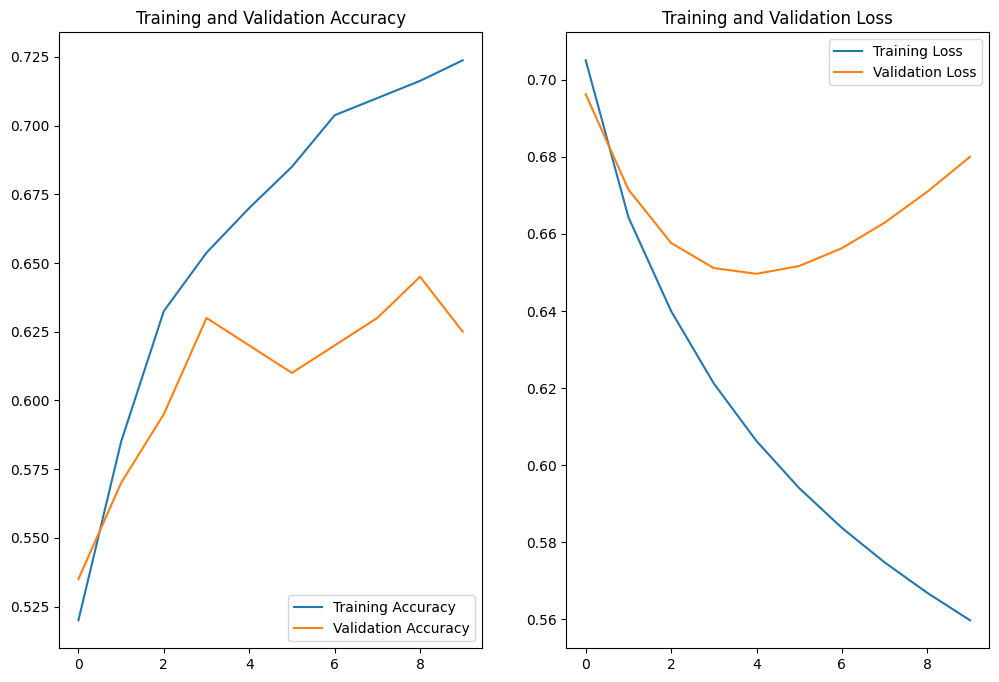

Evaluating model on validation data...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6200 - loss: 0.6496
Validation Loss: 0.6496
Validation Accuracy: 0.6200


In [7]:
import matplotlib.pyplot as plt

# Check if history exists to avoid NameError
if 'history' in globals():
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 8))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

    print("Evaluating model on validation data...")
    val_loss_eval, val_acc_eval = model.evaluate(val_ds)
    print(f"Validation Loss: {val_loss_eval:.4f}")
    print(f"Validation Accuracy: {val_acc_eval:.4f}")
else:
    print("Error: 'history' object not found. Please ensure the training cell (48cef2c5) completes successfully before running this evaluation.")

### Model Performance Summary

### Confusion Matrix (After Data Augmentation)

Let's re-evaluate the model's classification performance with a confusion matrix now that data augmentation has been applied during training.

In [8]:
print(f"Final Validation Accuracy: {val_acc_eval:.4f}")

print("\nCNN Model Architecture:")
model.summary()

Final Validation Accuracy: 0.6200

CNN Model Architecture:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,829 (8.63 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2,564 (10.02 KB)

### Confusion Matrix

A confusion matrix helps us evaluate the performance of a classification model by showing the number of correct and incorrect predictions made by the classifier, broken down by each class. It provides insights into false positives and false negatives.

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


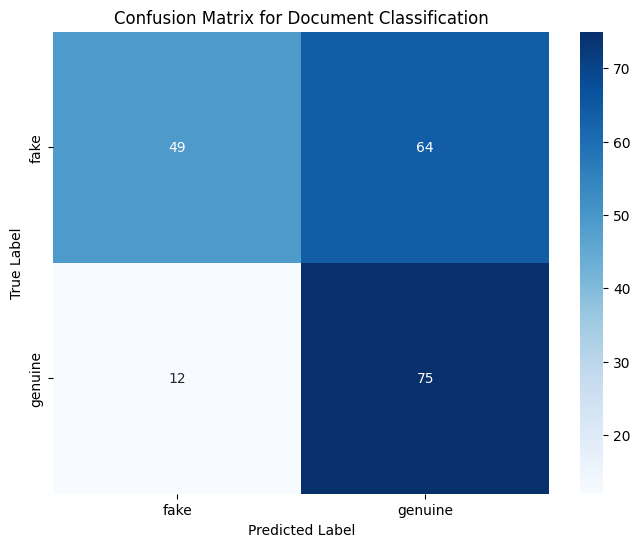

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get true labels and predictions from the validation set
val_labels = []
val_predictions = []

for images, labels in val_ds:
    val_labels.extend(labels.numpy())
    preds = model.predict(images)
    val_predictions.extend(preds.flatten())

# Convert probabilities to binary predictions (0 or 1)
# Assuming a threshold of 0.5 for sigmoid output
binary_predictions = [1 if p > 0.5 else 0 for p in val_predictions]

# Generate the confusion matrix
cm = confusion_matrix(val_labels, binary_predictions)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Document Classification')
plt.show()

### Screening System Inference

This function takes an image path, preprocesses it, and uses the trained model to determine if the identity document is likely genuine or fake.

In [10]:
import numpy as np
import tensorflow as tf
import os
from tensorflow.keras.preprocessing import image

def screen_document(img_path):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) # Create a batch
    img_array = img_array / 255.0 # Normalize

    # Make prediction
    prediction = model.predict(img_array)
    score = prediction[0][0]

    # Class 0 is 'fake', Class 1 is 'genuine' based on directory order
    result = "GENUINE" if score > 0.5 else "FAKE"
    confidence = score if score > 0.5 else 1 - score

    print(f"Screening Result: This document is {result} ({confidence*100:.2f}% confidence)")

# Updated test path to match the actual generated file naming convention (fake_0.png)
test_path = os.path.join(fake_dir, 'fake_0.png')

if os.path.exists(test_path):
    screen_document(test_path)
else:
    print(f"Error: The file {test_path} was not found. Please run the data generation cell first.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
Screening Result: This document is GENUINE (63.86% confidence)


In [11]:
import numpy as np
from PIL import Image, ImageDraw, ImageFont, ImageFilter
import os
import random

def add_noise(img):
    """Adds random Gaussian noise to the image."""
    img_array = np.array(img).astype(np.float32)
    noise = np.random.normal(0, 15, img_array.shape) # Increased noise intensity
    noisy_img = np.clip(img_array + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(noisy_img)

def add_distortion(img):
    """Applies a subtle distortion/warp effect."""
    # Applying a subtle affine transformation (shear, slight shift)
    img = img.transform(img.size, Image.AFFINE, (1, random.uniform(-0.05, 0.05), random.uniform(-10, 10),
                                                  0, 1, random.uniform(-0.05, 0.05)))
    return img

def generate_synthetic_document(is_fake=False, document_type='passport', img_idx=0):
    img_width, img_height = 800, 600
    # More varied and slightly textured backgrounds
    bg_color_base = (random.randint(220, 240), random.randint(220, 240), random.randint(220, 240))
    bg_img = Image.new('RGB', (img_width, img_height), color=bg_color_base)
    # Add some random lines or faint patterns to simulate paper texture
    draw_bg = ImageDraw.Draw(bg_img)
    for _ in range(5):
        line_color = (random.randint(200, 210), random.randint(200, 210), random.randint(200, 210))
        draw_bg.line([(random.randint(0, img_width), random.randint(0, img_height)),
                      (random.randint(0, img_width), random.randint(0, img_height))], fill=line_color, width=1)
    img = bg_img
    d = ImageDraw.Draw(img)

    # Try to load a more interesting font, or fall back to default
    try:
        font_path = '/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf'
        title_font = ImageFont.truetype(font_path, 36) if os.path.exists(font_path) else ImageFont.load_default()
        text_font = ImageFont.truetype(font_path, 24) if os.path.exists(font_path) else ImageFont.load_default()
        small_text_font = ImageFont.truetype(font_path, 18) if os.path.exists(font_path) else ImageFont.load_default()
    except Exception:
        title_font = ImageFont.load_default()
        text_font = ImageFont.load_default()
        small_text_font = ImageFont.load_default()

    # Base document content
    d.text((random.randint(50, 70), random.randint(50, 70)),
           f"{document_type.upper()} IDENTITY DOCUMENT", fill=(random.randint(30, 50), random.randint(30, 50), random.randint(30, 50)), font=title_font)
    d.text((random.randint(50, 70), random.randint(120, 140)),
           f"Name: {random.choice(['John Doe', 'Jane Smith', 'Alice Johnson', 'Bob Williams', 'Charlie Brown'])}",
           fill=(random.randint(0, 20), random.randint(0, 20), random.randint(0, 20)), font=text_font)
    d.text((random.randint(50, 70), random.randint(170, 190)),
           f"ID No: {random.randint(100000000, 999999999)}",
           fill=(random.randint(0, 20), random.randint(0, 20), random.randint(0, 20)), font=text_font)
    d.text((random.randint(50, 70), random.randint(220, 240)),
           f"DOB: {random.randint(1, 28):02d}/{random.randint(1, 12):02d}/{random.randint(1950, 2000)}",
           fill=(random.randint(0, 20), random.randint(0, 20), random.randint(0, 20)), font=text_font)
    d.text((random.randint(50, 70), random.randint(270, 290)),
           f"Nationality: {random.choice(['USA', 'CAN', 'GBR', 'AUS', 'GER', 'FRA', 'JPN', 'IND'])}",
           fill=(random.randint(0, 20), random.randint(0, 20), random.randint(0, 20)), font=text_font)

    # Simulate a photo placeholder
    photo_x, photo_y = random.randint(500, 600), random.randint(100, 150)
    photo_width, photo_height = 120, 150
    d.rectangle([photo_x, photo_y, photo_x + photo_width, photo_y + photo_height], fill=(random.randint(150, 200), random.randint(150, 200), random.randint(150, 200)), outline=(50,50,50))
    d.text((photo_x + 10, photo_y + photo_height // 2 - 10), "Photo", fill=(255,255,255), font=small_text_font)


    if is_fake:
        forgery_type = random.choice(['patch', 'blur', 'overlap', 'color_shift', 'watermark_alteration', 'photo_replacement', 'text_mismatch'])
        if forgery_type == 'patch':
            # Patch over some text
            patch_x = random.randint(100, 400)
            patch_y = random.randint(150, 300)
            patch_width = random.randint(100, 200)
            patch_height = random.randint(20, 40)
            d.rectangle([patch_x, patch_y, patch_x + patch_width, patch_y + patch_height], fill=(random.randint(200,230), random.randint(200,230), random.randint(200,230)))
            d.text((patch_x + 5, patch_y + 5), "FAKE DATA", fill=(random.randint(0, 100), random.randint(0, 100), random.randint(0, 100)), font=small_text_font)
        elif forgery_type == 'blur':
            # Blur a section of the document
            blur_x = random.randint(50, img_width - 200)
            blur_y = random.randint(100, img_height - 100)
            blur_region = img.crop((blur_x, blur_y, blur_x + 150, blur_y + 100))
            blur_region = blur_region.filter(ImageFilter.GaussianBlur(radius=random.uniform(1.5, 3)))
            img.paste(blur_region, (blur_x, blur_y))
        elif forgery_type == 'overlap':
            # Overlapping text/stamp
            d.text((random.randint(50, img_width-200), random.randint(350, img_height-100)),
                   random.choice(["VOID", "COPY", "INVALID", "UNAUTHORIZED"]),
                   fill=(random.randint(150, 200), random.randint(50, 100), random.randint(50, 100)),
                   font=title_font)
        elif forgery_type == 'color_shift':
            # Apply a color shift to a specific area
            shift_x = random.randint(50, img_width - 200)
            shift_y = random.randint(50, img_height - 200)
            shift_region = img.crop((shift_x, shift_y, shift_x + 150, shift_y + 150))
            shift_region_array = np.array(shift_region).astype(np.int32)
            color_offset = (random.randint(-30, 30), random.randint(-30, 30), random.randint(-30, 30))
            shifted_array = np.clip(shift_region_array + color_offset, 0, 255).astype(np.uint8)
            img.paste(Image.fromarray(shifted_array), (shift_x, shift_y))
        elif forgery_type == 'watermark_alteration':
            # Add a faint, distorted watermark
            watermark_text = random.choice(["SECRET", "CONFIDENTIAL", "DRAFT"])
            watermark_color = (random.randint(180, 220), random.randint(180, 220), random.randint(180, 220), 100) # Semi-transparent
            watermark_img = Image.new('RGBA', (img_width, img_height), (0,0,0,0))
            draw_wm = ImageDraw.Draw(watermark_img)
            draw_wm.text((random.randint(img_width//4, img_width//2), random.randint(img_height//4, img_height//2)),
                         watermark_text, fill=watermark_color, font=ImageFont.truetype(font_path, 70) if os.path.exists(font_path) else ImageFont.load_default(), anchor="mm")
            watermark_img = watermark_img.rotate(random.uniform(-30, 30), expand=True, fillcolor=(0,0,0,0))
            img.paste(watermark_img, (0, 0), watermark_img)
        elif forgery_type == 'photo_replacement':
            # Simulate a crudely replaced photo
            d.rectangle([photo_x, photo_y, photo_x + photo_width, photo_y + photo_height], fill=(random.randint(50, 100), random.randint(50, 100), random.randint(50, 100)), outline=(200, 0, 0), width=3)
            d.text((photo_x + 10, photo_y + photo_height // 2 - 10), "REPLACED", fill=(255,255,255), font=small_text_font)
        elif forgery_type == 'text_mismatch':
            # Change a single piece of text to something inconsistent
            # Overwrite name with a different, slightly off name
            d.text((random.randint(50, 70), random.randint(120, 140)),
                   f"Name: {random.choice(['Richard Roe', 'Betty White', 'Chris Green'])}",
                   fill=(random.randint(0, 20), random.randint(0, 20), random.randint(0, 20)), font=text_font)


    img = add_noise(img)
    img = add_distortion(img) # Add distortion
    img = img.filter(ImageFilter.SMOOTH)
    return img

dataset_dir = './dummy_document_data'
gen_dir = os.path.join(dataset_dir, 'genuine')
fake_dir = os.path.join(dataset_dir, 'fake')

# Clear existing directories to avoid mixing old and new data
if os.path.exists(gen_dir):
    for f in os.listdir(gen_dir):
        os.remove(os.path.join(gen_dir, f))
else:
    os.makedirs(gen_dir, exist_ok=True)

if os.path.exists(fake_dir):
    for f in os.listdir(fake_dir):
        os.remove(os.path.join(fake_dir, f))
else:
    os.makedirs(fake_dir, exist_ok=True)


print("Generating improved synthetic documents...")
num_samples = 500 # Increased number of samples
for i in range(num_samples):
    generate_synthetic_document(is_fake=False, img_idx=i).save(os.path.join(gen_dir, f"gen_{i}.png"))
    generate_synthetic_document(is_fake=True, img_idx=i).save(os.path.join(fake_dir, f"fake_{i}.png"))

print(f"Success: Generated {num_samples*2} more realistic images.")

Generating improved synthetic documents...
Success: Generated 1000 more realistic images.


In [14]:
import shutil
from google.colab import files

# Define the name for the zip archive
archive_name = 'dummy_document_data'
output_filename = f'{archive_name}.zip'

# Create a zip archive of the dataset_dir
shutil.make_archive(archive_name, 'zip', dataset_dir)

print(f"Dataset compressed to '{output_filename}'.")
print("Initiating download...")

# Offer the file for download
files.download(output_filename)

Dataset compressed to 'dummy_document_data.zip'.
Initiating download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
%%capture
!pip install gradio

### AI Identity Screening Interface
Run the cell below to launch the interactive frontend.

In [13]:
import tensorflow as tf
import numpy as np
import gradio as gr
from tensorflow.keras.preprocessing import image
import functools # Import functools for partial
from tensorflow.keras import layers, models # Import layers and models for model definition

# Define IMG_HEIGHT and IMG_WIDTH if not already defined in the global scope.
# These values are crucial for the model definition and were set in previous cells.
IMG_HEIGHT = 224
IMG_WIDTH = 224

# Re-define the model architecture if it's not already present in the global scope.
# This resolves the 'NameError' by ensuring the 'model' object exists.
# IMPORTANT: For the Gradio interface to use a TRAINED model, ensure the training cell
# (cell ID 48cef2c5) is executed successfully before running this cell.
# Otherwise, this will create an untrained model architecture.
if 'model' not in globals():
    model = models.Sequential([
        layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid') # Sigmoid for binary classification
    ])
    print("Warning: 'model' was not found in global scope. Re-creating model architecture (untrained). Please run training cell (ID 48cef2c5) for a trained model.")


def gradio_screen(img, model_instance):
    # Define IMG_HEIGHT and IMG_WIDTH locally to ensure they are always in scope
    # (these are also defined globally above for model creation, ensuring consistency)
    IMG_HEIGHT = 224
    IMG_WIDTH = 224

    if img is None:
        return "Please upload an image to begin."

    # Preprocess the image
    img_resized = tf.image.resize(img, (IMG_HEIGHT, IMG_WIDTH))
    img_array = tf.expand_dims(img_resized, 0) / 255.0

    # Prediction using the passed model_instance
    prediction = model_instance.predict(img_array)
    score = float(prediction[0][0])

    # Logic: 0 = Fake, 1 = Genuine
    label = "GENUINE" if score > 0.5 else "FAKE"
    confidence = score if score > 0.5 else 1 - score

    color = "#4CAF50" if label == "GENUINE" else "#F44336"

    return f"### Result: <span style='color:{color}'>{label}</span>\n**Confidence:** {confidence*100:.2f}%"

# Launch Gradio Interface
# share=True is required for Colab
interface = gr.Interface(
    fn=functools.partial(gradio_screen, model_instance=model), # Pass the global 'model' here
    inputs=gr.Image(label="Upload Identity Document or Use Webcam", sources=["upload", "webcam"]),
    outputs=gr.Markdown(label="Analysis Result"),
    title="AI Document Screening System",
    description="Upload a scan of an identity document or use your webcam to check for authenticity. The model analyzes visual features to detect potential forgeries.",
    flagging_mode="never"
)

interface.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://4be70b1c331a08a34a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://4be70b1c331a08a34a.gradio.live
